In [7]:
import torch
from sklearn.model_selection import train_test_split

import os
import time


# Custom Libraries
from utils.data_generator import DataGenerator
from utils.agent import TrainModel
from utils.helper import to_python_native, gen_experiment_name, set_seed, save_model_state
from utils.pennylane.model import Qkernel

ModuleNotFoundError: No module named 'utils'

In [2]:
# === Backend Configuration ===
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

set_seed(42)
device

device(type='mps')

In [3]:
data_generator = DataGenerator(
        dataset_name= 'checkerboard',
        file_path= 'data/checkerboard_dataset.npy',
    )

training_data, training_labels, testing_data, testing_labels = data_generator.generate_dataset()
training_data = torch.tensor(training_data.to_numpy(), dtype=torch.float32, requires_grad=True)
testing_data = torch.tensor(testing_data.to_numpy(), dtype=torch.float32, requires_grad=True)
training_labels = torch.tensor(training_labels.to_numpy(), dtype=torch.int)
testing_labels = torch.tensor(testing_labels.to_numpy(), dtype=torch.int)

In [10]:
## Check the difference in target kernel alignments

def kernel_alignment(K_noisy: torch.Tensor,
                     K_clean: torch.Tensor,
                     center: bool = False,
                     eps: float = 1e-12) -> torch.Tensor:
    """
    Compute normalized kernel alignment between two kernel matrices:
        A(K1, K2) = <K1, K2>_F / (||K1||_F * ||K2||_F)
    Optionally applies double-centering: Kc = H K H, where H = I - (1/n) 11^T.

    Args:
        K_noisy: (N, N) kernel matrix from noisy backend.
        K_clean: (N, N) kernel matrix from ideal/clean backend.
        center:  If True, double-center both kernels before alignment.
        eps:     Small constant for numerical stability.

    Returns:
        Scalar torch.Tensor with alignment in [-1, 1].
    """
    # Ensure tensors and shapes
    if not torch.is_tensor(K_noisy): K_noisy = torch.tensor(K_noisy, dtype=torch.float32)
    if not torch.is_tensor(K_clean): K_clean = torch.tensor(K_clean, dtype=torch.float32)
    assert K_noisy.shape == K_clean.shape and K_noisy.dim() == 2 and K_noisy.shape[0] == K_noisy.shape[1], \
        "Both kernels must be square and of the same shape (N, N)."

    # Work on a common device/dtype
    device = K_noisy.device
    K1 = K_noisy.to(device=device, dtype=torch.float32)
    K2 = K_clean.to(device=device, dtype=torch.float32)

    if center:
        n = K1.shape[0]
        I = torch.eye(n, device=device, dtype=K1.dtype)
        one = torch.ones((n, 1), device=device, dtype=K1.dtype)
        H = I - (one @ one.t()) / n  # centering matrix
        K1 = H @ K1 @ H
        K2 = H @ K2 @ H

    # Frobenius inner product and norms
    num = torch.sum(K1 * K2)
    den = torch.sqrt(torch.sum(K1 * K1) + eps) * torch.sqrt(torch.sum(K2 * K2) + eps)

    return (num / den).squeeze()

In [4]:
training_labels = training_labels.float()
training_labels

tensor([-1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1., -1., -1.,
        -1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1., -1., -1.,  1.,  1.,  1.,
         1., -1.])

p = 0.010 .....p = 0.020 .....p = 0.030 .....p = 0.040 .....p = 0.050 .....p = 0.060 .....p = 0.070 .....p = 0.080 .....p = 0.090 .....

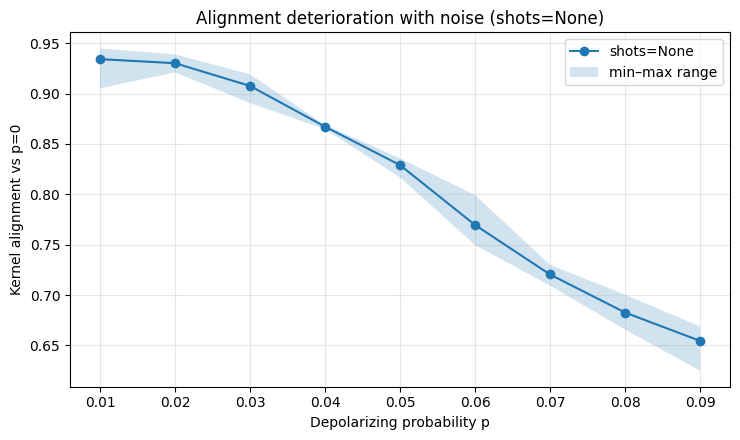

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

shots = None
p_list = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
n_repeats = 5   # how many times to resample each point

grad =  "backprop"

N = training_data.shape[0]
x_0 = training_data.repeat(N, 1)
x_1 = training_data.repeat_interleave(N, dim=0)

# Reference kernel (p=0)
kernel_ref = Qkernel(
    device="default.mixed", n_qubits=4, trainable=True, input_scaling=True,
    data_reuploading=True, ansatz="embedding_paper", ansatz_layers=5,
    noise_prob=0.0, diff_method=grad, shots=shots
)
K0 = kernel_ref(x_0, x_1).to(torch.float32).reshape(N, N).detach()

means, lowers, uppers = [], [], []

for p in p_list:
    vals = []
    print(f"p = {p:.3f} ", end="")
    for rep in range(n_repeats):
        # new kernel each time (forces new sampling noise)
        print(".", end="", flush=True)
        Nkernel = Qkernel(
            device="default.mixed", n_qubits=4, trainable=True, input_scaling=True,
            data_reuploading=True, ansatz="embedding_paper", ansatz_layers=5,
            noise_prob=p, diff_method=grad, shots=shots
        )
        Kp = Nkernel(x_0, x_1).to(torch.float32).reshape(N, N).detach()
        a = kernel_alignment(Kp, K0)
        vals.append(float(a.detach().cpu()) if torch.is_tensor(a) else float(a))
    arr = np.array(vals)
    means.append(arr.mean())
    lowers.append(arr.min())
    uppers.append(arr.max())

# --- plot with uncertainty band ---
plt.figure(figsize=(7.5,4.5))
plt.plot(p_list, means, marker='o', label=f"shots={shots}")
plt.fill_between(p_list, lowers, uppers, alpha=0.2, label="min–max range")
plt.xlabel("Depolarizing probability p")
plt.ylabel("Kernel alignment vs p=0")
plt.title(f"Alignment deterioration with noise (shots={shots})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt

clusters_list = [2, 4, 6, 8, 10]
shots = None
p_list = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09]
repeats = 5
grad = "backprop"  # analytic mode (shots=None)

# Optional: for reproducibility across repeats
torch.manual_seed(42)
np.random.seed(42)

acc_by_p = {p: [] for p in p_list}

for p in p_list:
    print(f"p = {p:.3f} ", end="")
    for c in clusters_list:
        print(f"c={c} ", end="")
        for rep in range(repeats):
            
            Nkernel = Qkernel(
                device="default.mixed",
                n_qubits=4,
                trainable=True,
                input_scaling=True,
                data_reuploading=True,
                ansatz="embedding_paper",
                ansatz_layers=5,
                noise_prob=p,
                diff_method=grad,
                shots=shots,
            )

            agent = TrainModel(
                kernel=Nkernel,
                training_data=training_data,
                training_labels=training_labels,
                testing_data=testing_data,
                testing_labels=testing_labels,
                optimizer="gd",
                lr=0.1,
                mclr=0.01,
                cclr=0.01,
                epochs=100,
                train_method="random",
                target_accuracy=0.95,
                get_alignment_every=500,
                validate_every_epoch=1,
                base_path="../",
                lambda_kao=0.001,
                lambda_co=0.001,
                clusters=c,        # <-- use the loop's cluster count
                use_kmeans=True
            )

            _ = agent.fit_kernel(training_data, training_labels)
            after_metrics = agent.evaluate(testing_data, testing_labels, "after")
            acc = float(after_metrics["testing_accuracy"])
            acc_by_p[p].append(acc)
            print(".", end="", flush=True)
        print('')
    print(f" mean acc={np.mean(acc_by_p[p]):.3f}")

# Prepare arrays for plotting
p_vals = np.array(p_list, dtype=float)
means  = np.array([np.mean(acc_by_p[p]) for p in p_list])
mins   = np.array([np.min(acc_by_p[p])  for p in p_list])
maxs   = np.array([np.max(acc_by_p[p])  for p in p_list])
stds   = np.array([np.std(acc_by_p[p])  for p in p_list])

plt.figure(figsize=(8, 5))
plt.plot(p_vals, means, marker="o", label="CCKA mean accuracy")
plt.fill_between(p_vals, mins, maxs, alpha=0.20, label="min–max")
# Optional: a tighter inner band (mean ± 1 std)
plt.fill_between(p_vals, means - stds, means + stds, alpha=0.15, label="±1σ")

plt.xlabel("Depolarizing probability p")
plt.ylabel("Test accuracy")
plt.title("CCKA accuracy vs noise with uncertainty bands")
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

p = 0.010 c=2 Epochs:  100
Started Training


KeyboardInterrupt: 

In [1]:
def plot_acc_vs_noise(
    data,
    clusters=(2, 4, 6, 8, 10),
    metric="test_accuracy",
    dataset=None,
    method=None,
    ax=None,
    bounds="minmax",          # 'minmax' | 'std' | 'quantile'
    std_mult=1.0,             # for bounds='std' -> mean ± std_mult*std
    quantiles=(0.1, 0.9),     # for bounds='quantile' -> (lo, hi)
    show_points=True,
    clip=(0.0, 1.0)           # clip y to a range; set None to disable
):
    """
    Plot accuracy vs. noise_level with one line per subcentroid count (k),
    and show upper/lower bounds per k across repeated runs at each noise level.

    data : pandas.DataFrame | str
        DataFrame with columns ['noise_level','subcentroids', <metric>]
        OR CSV path OR CSV string (with header).
    bounds : str
        'minmax'    -> lower=min, upper=max
        'std'       -> lower=mean-std_mult*std, upper=mean+std_mult*std
        'quantile'  -> lower=Q[quantiles[0]], upper=Q[quantiles[1]]
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from io import StringIO

    # --- load to DataFrame ---
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    elif isinstance(data, str):
        if "\n" in data and "," in data and ("dataset" in data.splitlines()[0]):
            df = pd.read_csv(StringIO(data))
        else:
            df = pd.read_csv(data)
    else:
        raise TypeError("data must be a pandas.DataFrame, a CSV path, or a CSV string")

    # --- hygiene ---
    need = {"noise_level", "subcentroids", metric}
    if not need.issubset(df.columns):
        missing = need - set(df.columns)
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["noise_level"] = pd.to_numeric(df["noise_level"], errors="coerce")
    df["subcentroids"] = pd.to_numeric(df["subcentroids"], errors="coerce").astype("Int64")
    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=["noise_level", "subcentroids", metric])

    if dataset is not None and "dataset" in df.columns:
        df = df[df["dataset"] == dataset]
    if method is not None and "method" in df.columns:
        df = df[df["method"] == method]

    # --- plotting ---
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5))
        created_fig = True

    xticks_all = sorted(df["noise_level"].unique())
    markers = ["o", "s", "^", "D", "X", "v", "<", ">", "h", "P"]

    for i, k in enumerate(clusters):
        d = df[df["subcentroids"] == k]
        if d.empty:
            continue

        # aggregate per noise level
        g = (
            d.groupby("noise_level", as_index=True)[metric]
            .agg(["mean", "std", "min", "max", "count"])
            .sort_index()
        )

        x = g.index.values
        y_mean = g["mean"].values

        # compute bounds
        if bounds == "minmax":
            y_lo = g["min"].values
            y_hi = g["max"].values
        elif bounds == "std":
            std = g["std"].fillna(0).values
            y_lo = y_mean - std_mult * std
            y_hi = y_mean + std_mult * std
        elif bounds == "quantile":
            q = (
                d.groupby("noise_level")[metric]
                .quantile([quantiles[0], quantiles[1]])
                .unstack(level=1)
                .sort_index()
            )
            # handle missing quantiles gracefully
            lo_key, hi_key = quantiles
            y_lo = q.get(lo_key, q.iloc[:, 0]).values
            y_hi = q.get(hi_key, q.iloc[:, -1]).values
        else:
            raise ValueError("bounds must be 'minmax', 'std', or 'quantile'")

        if clip is not None:
            y_mean = np.clip(y_mean, clip[0], clip[1])
            y_lo = np.clip(y_lo, clip[0], clip[1])
            y_hi = np.clip(y_hi, clip[0], clip[1])

        # mean line
        ax.plot(x, y_mean, marker=markers[i % len(markers)], label=f"k={int(k)}")

        # shaded band + bound lines
        ax.fill_between(x, y_lo, y_hi, alpha=0.12)
        ax.plot(x, y_lo, linestyle="--", linewidth=1)
        ax.plot(x, y_hi, linestyle="--", linewidth=1)

        # scatter all runs lightly
        if show_points:
            ax.scatter(d["noise_level"].values, d[metric].values, s=16, alpha=0.35)

    ax.set_xlabel("Noise level")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title("Accuracy vs Noise Level by Sub-centroids (k)")
    ax.set_xticks(xticks_all)
    if clip is not None:
        ax.set_ylim(*clip)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Sub-centroids")

    if created_fig:
        plt.tight_layout()
        plt.show()

    return ax


In [ ]:
import pandas as pd
df_all = pd.read_csv("../noise_results/checkerboard/per_run_summary.csv")

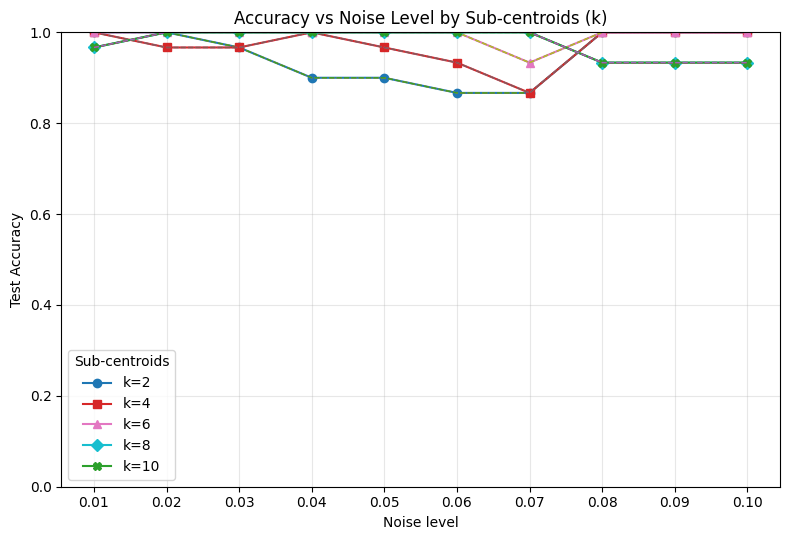

<Axes: title={'center': 'Accuracy vs Noise Level by Sub-centroids (k)'}, xlabel='Noise level', ylabel='Test Accuracy'>

In [ ]:
# 1) Single panel, aggregate across k
plot_methods_vs_noise(df_all, methods=("ccka","standard"), metric="test_accuracy",
                      k=None, bounds="std", std_mult=1.0)

# 2) Compare at a specific k (say k=6)
plot_methods_vs_noise(df_all, methods=("ccka","standard"), metric="test_accuracy",
                      k=6, bounds="minmax")

# 3) Faceted by k (small multiples)
plot_methods_vs_noise(df_all, methods=("ccka","standard"), metric="test_accuracy",
                      facet_by_k=True, bounds="quantile", quantiles=(0.1, 0.9))

# 4) Robustness table
noise_robustness_table(df_all, methods=("ccka","standard"), metric="test_accuracy")